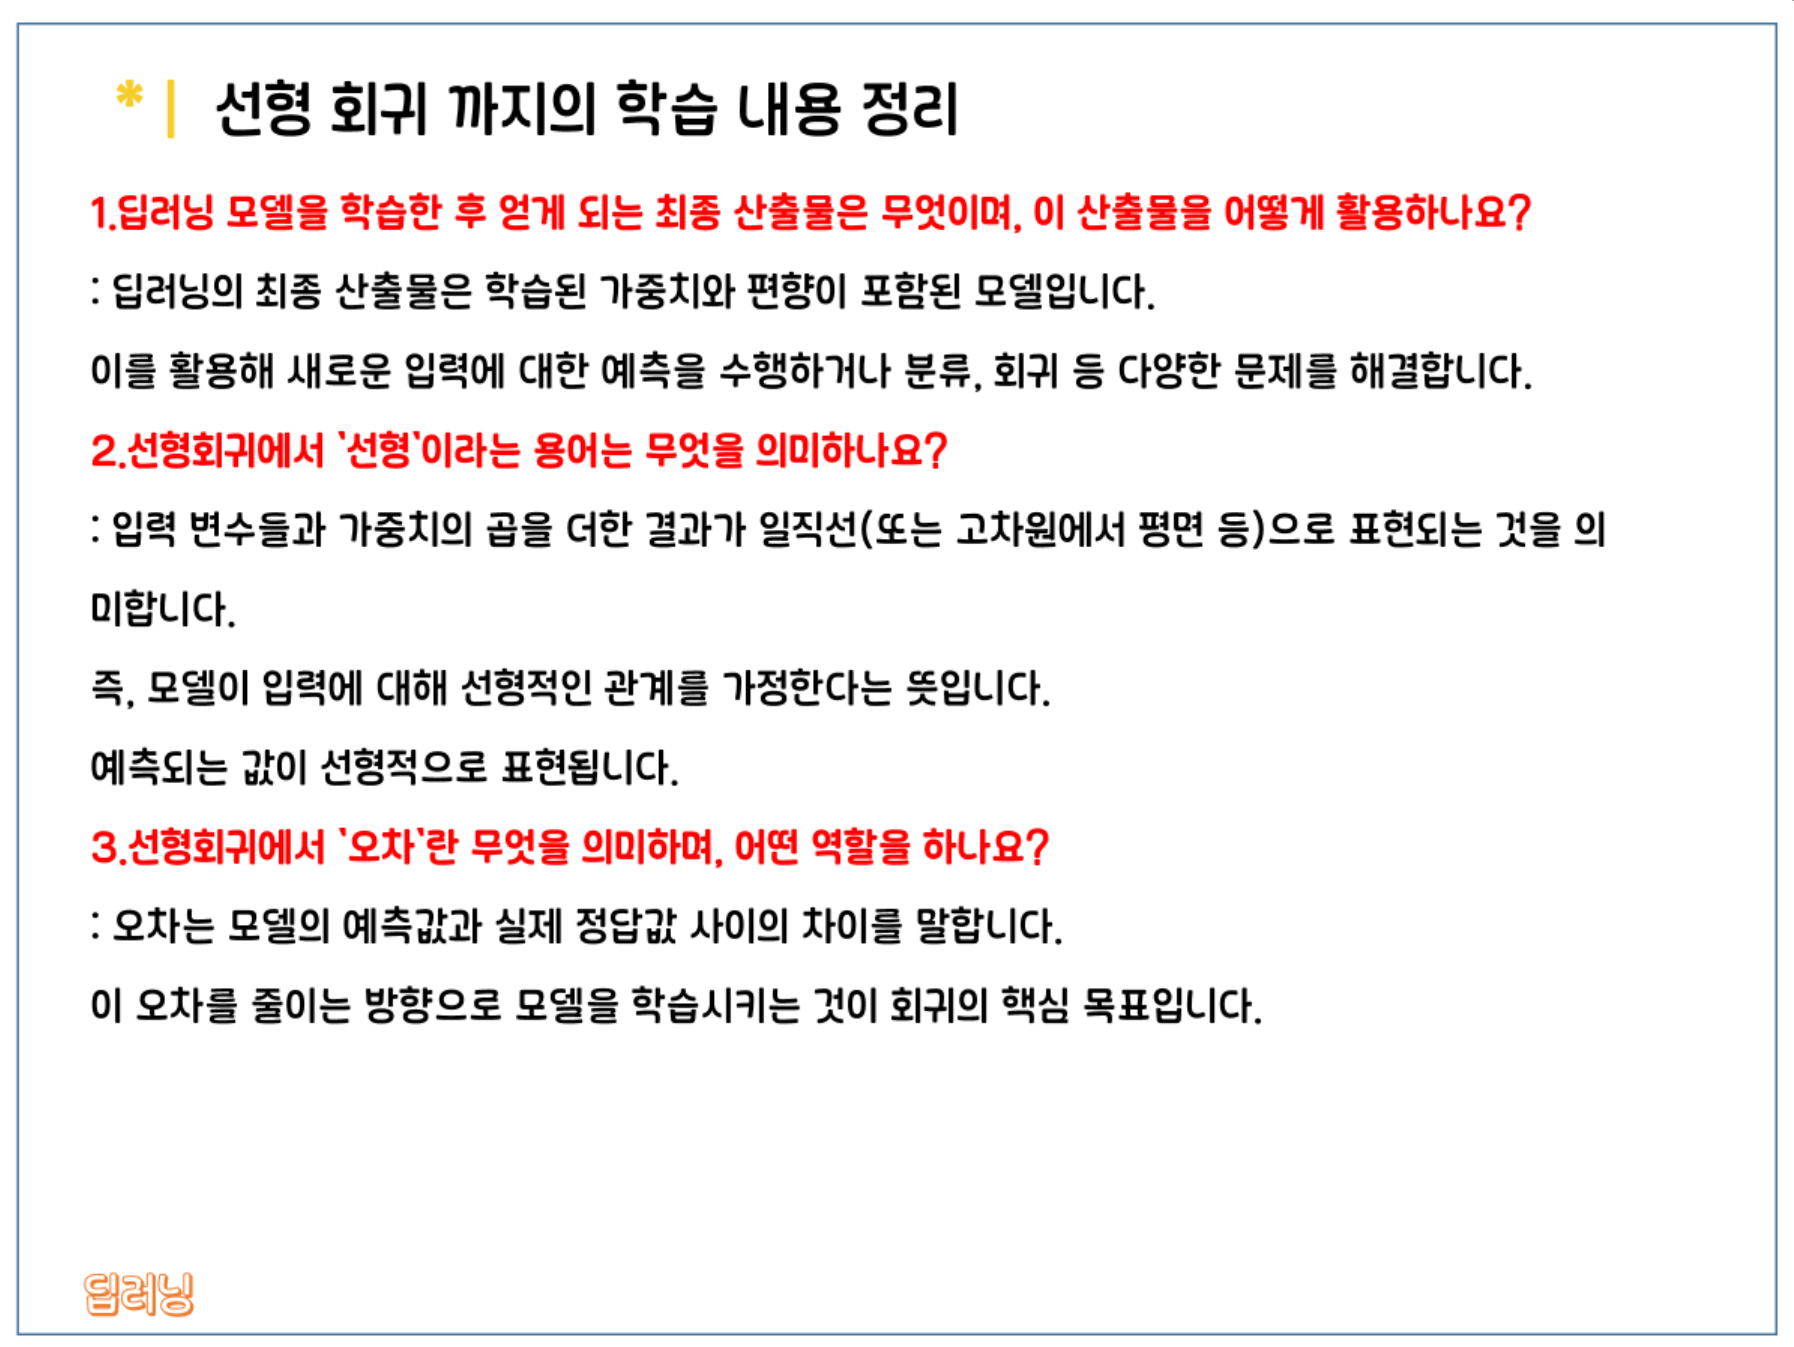

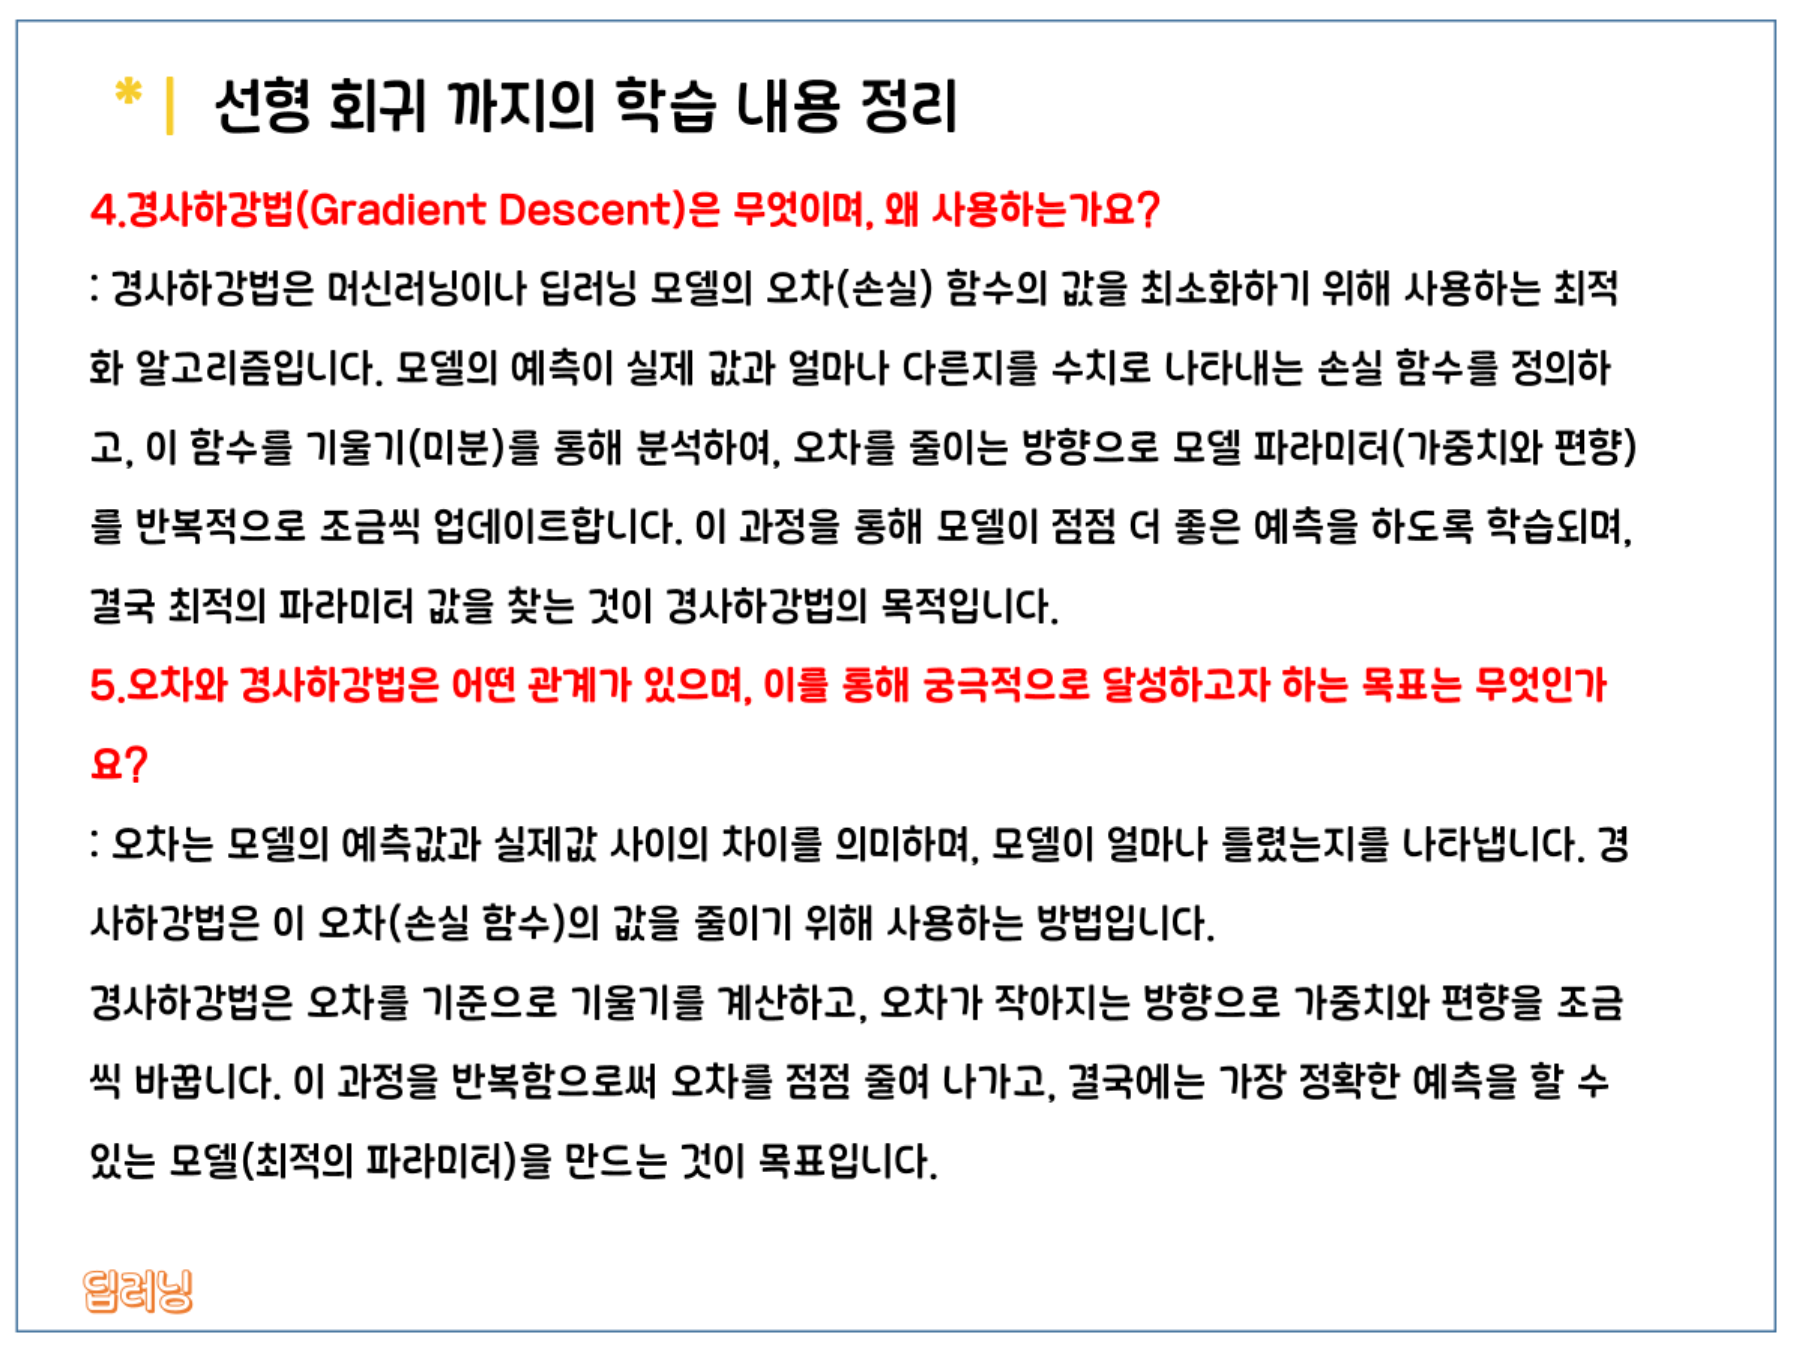

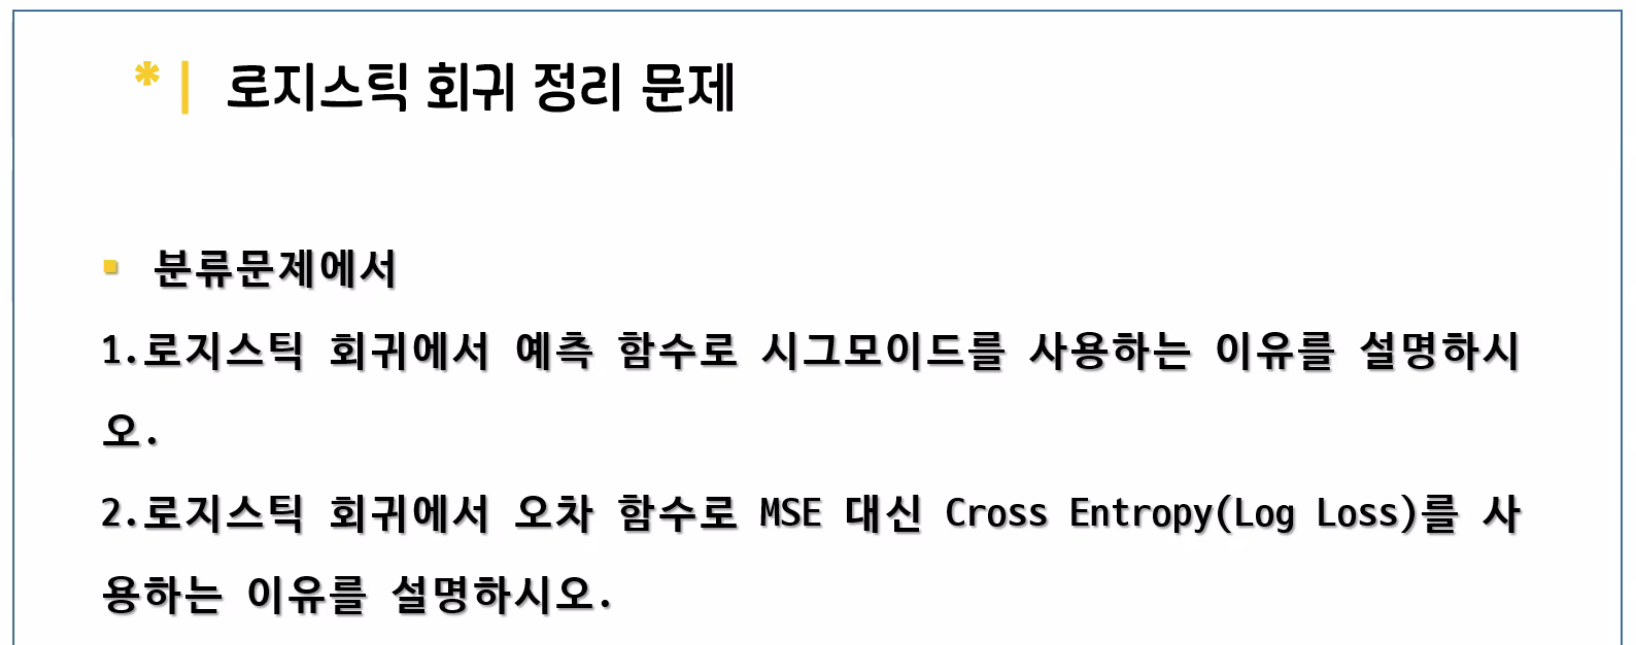

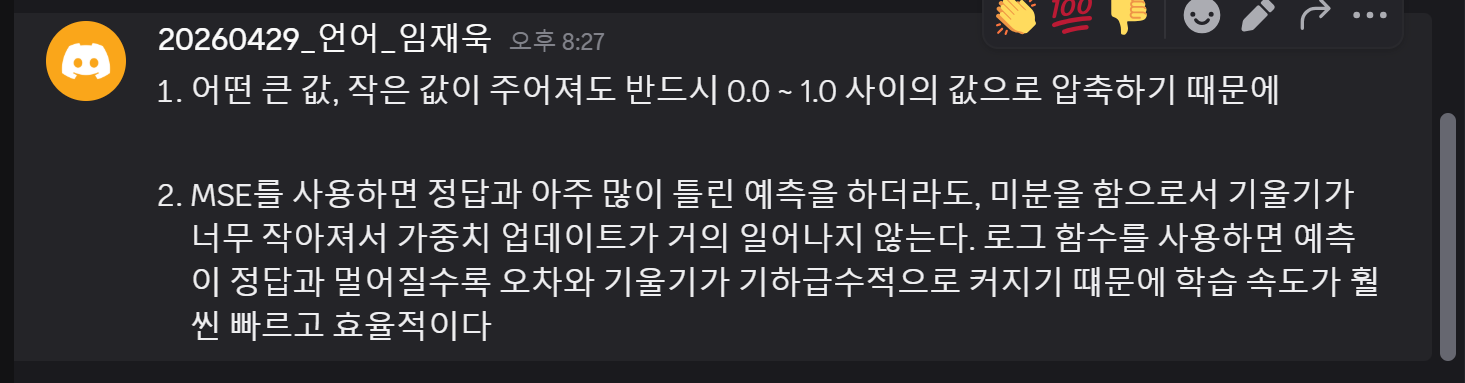

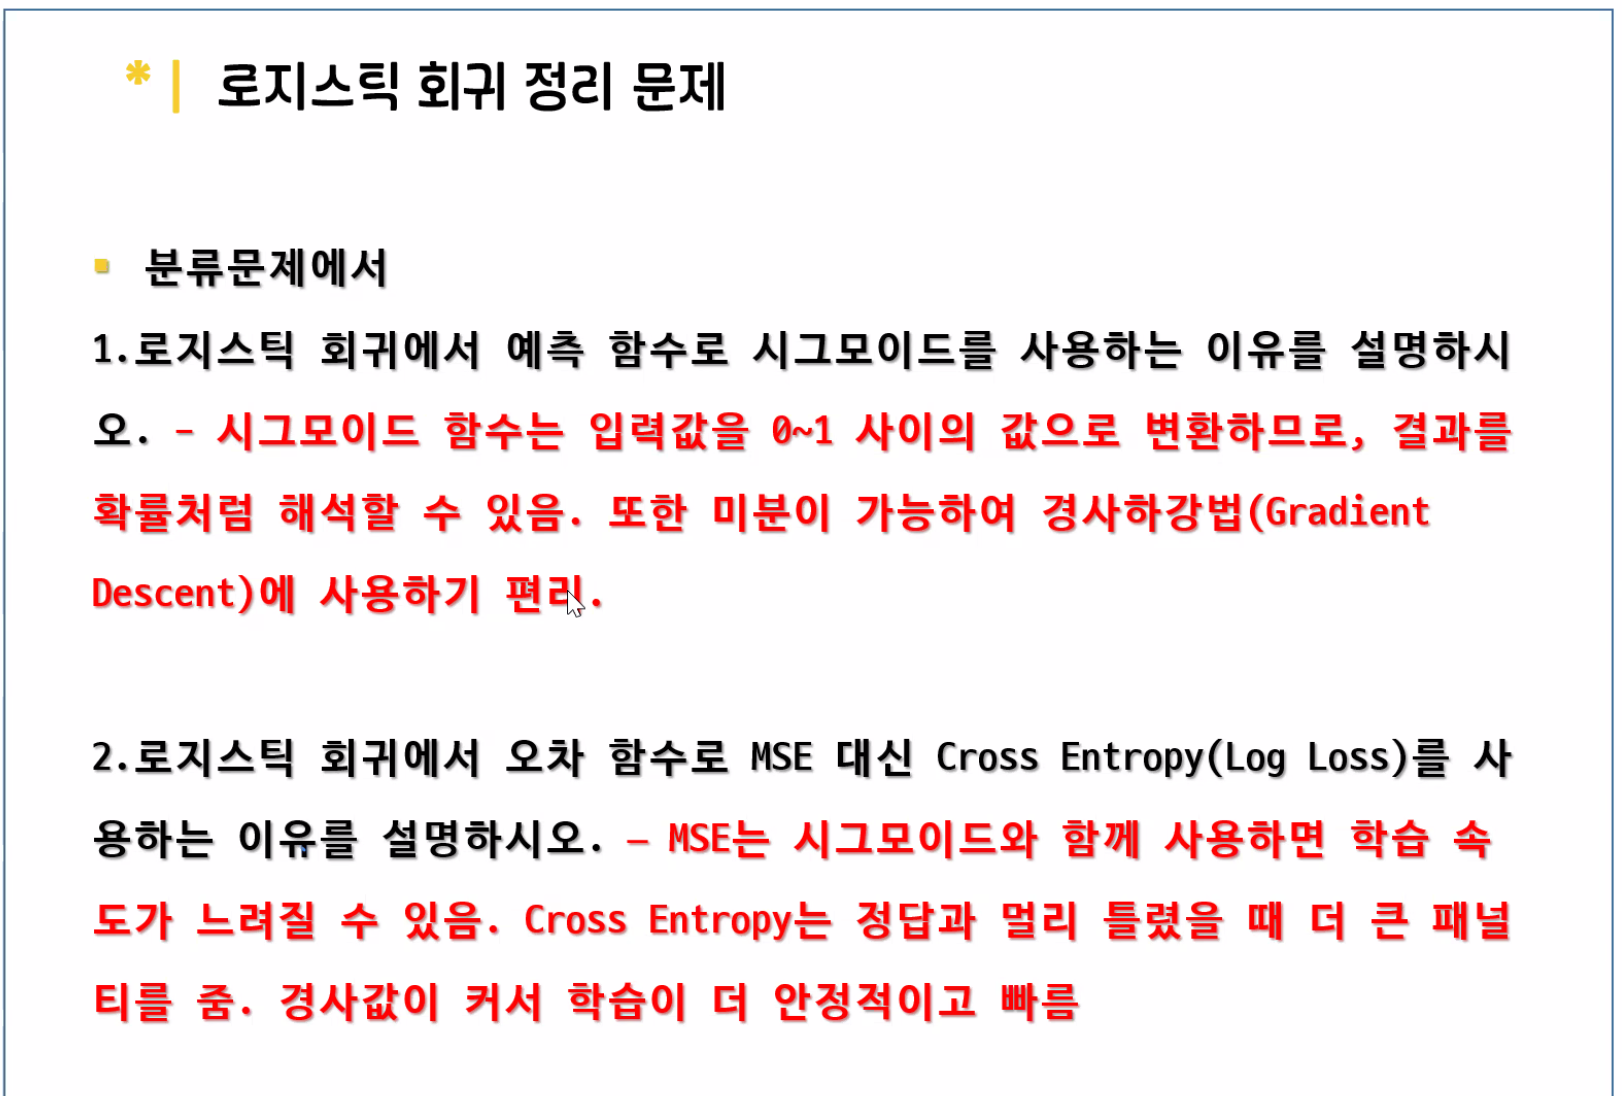

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# 1. 데이터 정의
# 운동시간(x), 감량여부(y) : 3시간 운동하면 실패, 21시간 운동하면 성공(분류)
data = [[3, 0], [6, 0], [9, 0], [12, 1], [15, 1], [18, 1], [21, 1]]
x_data = np.array([x for x, _ in data], dtype=np.float64)
y_data = np.array([y for _, y in data], dtype=np.float64)

# 2. 변수 a, b 초기값 설정
a = tf.Variable(tf.random.normal([1], dtype=tf.float64, seed=0))
b = tf.Variable(tf.random.normal([1], dtype=tf.float64, seed=0))

# 3. 시그모이드 함수 (가설)
def hypothesis(a, b):
    return 1 / (1 + tf.math.exp(-(a * x_data + b)))

# 4. 손실 함수 (Binary Cross Entropy)
def cost(a, b):
    return -tf.reduce_mean(y_data * tf.math.log(hypothesis(a, b) + 1e-7) +
        (1 - y_data) * tf.math.log(1 - hypothesis(a, b) + 1e-7))

# 5. 최적화 함수 (경사 하강법)
# optimizer = tf.keras.optimizers.SGD(learning_rate=0.5)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.1)

# 6. 학습 루프
for i in range(5001):
    with tf.GradientTape() as tape:
        current_cost = cost(a, b)
    grads = tape.gradient(current_cost, [a, b])
    optimizer.apply_gradients(zip(grads, [a, b]))

    if i % 500 == 0:
        print(f"Step: {i}, Cost: {current_cost.numpy():.6f}, a: {a.numpy()}, b: {b.numpy()}")

# 7. 학습 결과 출력
print(f"\n최종 결과 - a: {a.numpy()}, b: {b.numpy()}")

# 8. 예측
new_x = tf.constant([5.0, 16.0, 15.0], dtype=tf.float64)

def predict(x, a, b) :
    logits = a * x + b
    return 1 / (1 + tf.exp(-logits))
predictions = predict(new_x, a, b)

for x_val, p in zip(new_x.numpy(), predictions.numpy()) :
    print(f"x={x_val:.1f} -> 예측 확률 : {p:.4f} -> 클래스 : {'1' if p>=0.5 else '0'}")

Step: 0, Cost: 6.157738, a: [-0.53436735], b: [-0.20143917]
Step: 500, Cost: 0.071938, a: [0.90226008], b: [-9.28365113]
Step: 1000, Cost: 0.036389, a: [1.3518488], b: [-14.04107967]
Step: 1500, Cost: 0.021411, a: [1.71338108], b: [-17.8482238]
Step: 2000, Cost: 0.013628, a: [2.02081483], b: [-21.08104965]
Step: 2500, Cost: 0.009145, a: [2.29092379], b: [-23.91966691]
Step: 3000, Cost: 0.006371, a: [2.53461427], b: [-26.47985212]
Step: 3500, Cost: 0.004561, a: [2.75926719], b: [-28.83960611]
Step: 4000, Cost: 0.003332, a: [2.96997753], b: [-31.05265779]
Step: 4500, Cost: 0.002470, a: [3.17033301], b: [-33.15679713]
Step: 5000, Cost: 0.001852, a: [3.36290865], b: [-35.17912822]

최종 결과 - a: [3.36290865], b: [-35.17912822]
x=5.0 -> 예측 확률 : 0.0000 -> 클래스 : 0
x=16.0 -> 예측 확률 : 1.0000 -> 클래스 : 1
x=15.0 -> 예측 확률 : 1.0000 -> 클래스 : 1


In [ ]:
# 다중 로지스틱 회귀

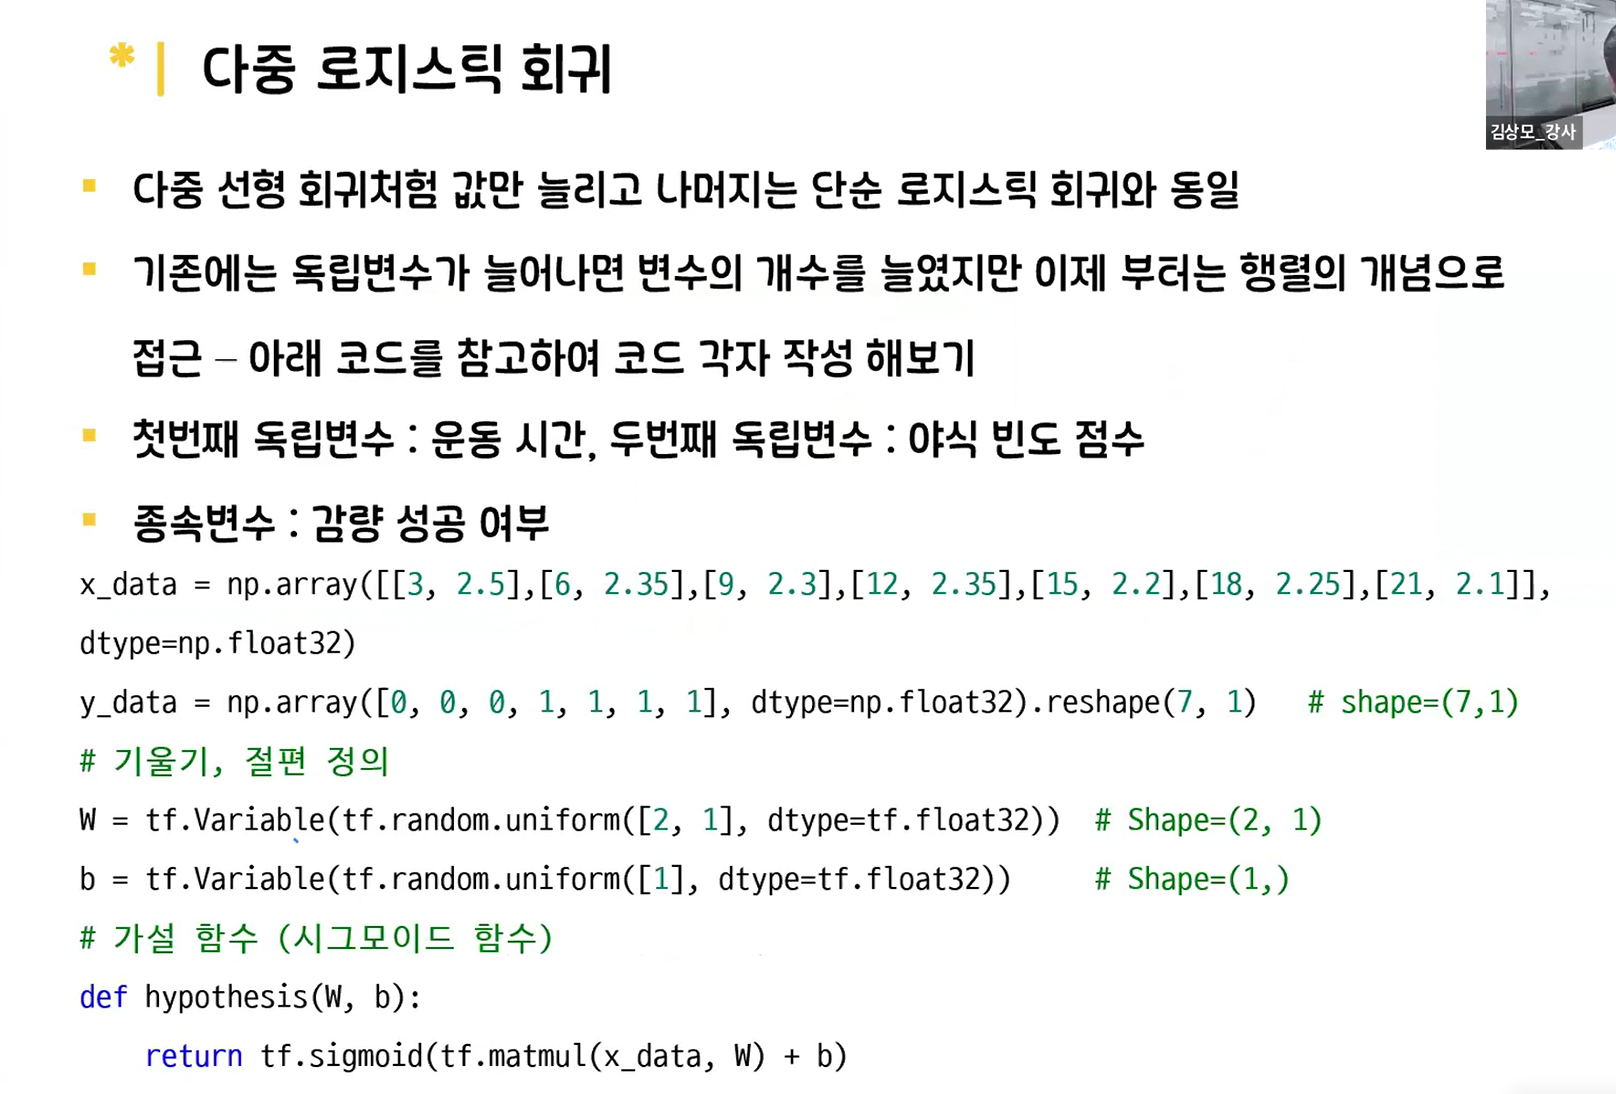

epochs=0, cost=1.233536958694458, W1=0.05186009407043457, W2=0.11222440749406815,b=[0.51577675]
epochs=200, cost=0.12693656980991364, W1=0.5854681730270386, W2=-2.322868824005127,b=[-0.4994475]
epochs=400, cost=0.09230345487594604, W1=0.7740201950073242, W2=-3.05495285987854,b=[-0.82429284]
epochs=600, cost=0.07557332515716553, W1=0.907448410987854, W2=-3.5656251907348633,b=[-1.0554142]
epochs=800, cost=0.0648353174328804, W1=1.0149544477462769, W2=-3.974669933319092,b=[-1.2424564]
epochs=1000, cost=0.057081498205661774, W1=1.1065508127212524, W2=-4.322098731994629,b=[-1.4022954]
epochs=1200, cost=0.051112834364175797, W1=1.187033772468567, W2=-4.626800537109375,b=[-1.5430288]
epochs=1400, cost=0.046329937875270844, W1=1.2591478824615479, W2=-4.899479389190674,b=[-1.6693053]
epochs=1600, cost=0.042389459908008575, W1=1.3246461153030396, W2=-5.146927833557129,b=[-1.784112]
epochs=1800, cost=0.03907597064971924, W1=1.3847370147705078, W2=-5.373802185058594,b=[-1.8895134]
epochs=2000, cos

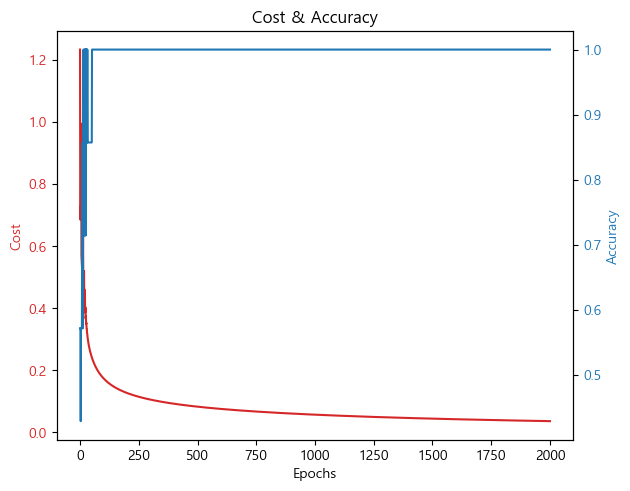

W = [[ 1.4402976]
 [-5.583471 ]]
b = -1.987021
y_data = [[0.]
 [0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]]
sigmoid = [[8.9414370e-06]
 [1.5524131e-03]
 [1.3396755e-01]
 [8.9801806e-01]
 [9.9934733e-01]
 [9.9998856e-01]
 [9.9999994e-01]]
predicted = [[0.]
 [0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]]
Accuracy = 1.0
운동 시간 : 13, 야식 스코어 : 2
감량성공 가능성 :  98.85 % :
예측 결과 : 감량


In [19]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import mat_kor

def graph() :
    fig, ax1 = plt.subplots()
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Cost', color='tab:red')

    ax1.plot(epoch_arr, cost_arr, color='tab:red', label='Cost')
    ax1.tick_params(axis='y', labelcolor='tab:red')

    ax2 = ax1.twinx() # x축 공유
    ax2.set_ylabel('Accuracy', color='tab:blue')
    ax2.plot(epoch_arr, accuracy_arr, color='tab:blue', label='Accuracy')
    ax2.tick_params(axis='y', labelcolor='tab:blue')

    fig.tight_layout()
    plt.title("Cost & Accuracy")
    plt.show()

# 시드 설정
seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

# 데이터 값 (※주의: 반드시 float로 정의해 주어야 함)
# TensorFlow의 수학 연산(exp, log, sigmoid)은 float 타입만 지원
# int 타입 입력은 형변환 오류 또는 학습 불가능 문제가 발생할 수 있음
# 학습(Optimizer)과 Gradient 연산은 float만 허용
# shape=(7, 1)
x_data = np.array([[3, 2.5], [6, 2.35], [9, 2.3], [12, 2.35], [15, 2.2], [18, 2.25], [21, 2.1]],dtype=np.float32)
y_data = np.array([0, 0, 0, 1, 1, 1, 1], dtype=np.float32).reshape(7, 1)  # shape=(7,1) [[0, 0, 0, 1, 1, 1, 1]]

# 기울기, 절편 정의
W = tf.Variable(tf.random.uniform([2, 1], dtype=tf.float32))  # Shape=(2, 1)
b = tf.Variable(tf.random.uniform([1], dtype=tf.float32))     # Shape=(1, ) (ex : [0.5])

# 가설 함수 (시그모이드 함수)
def hypothesis(W, b):
    return tf.sigmoid(tf.matmul(x_data, W) + b) # 브로드캐스팅 (b절편 => [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5])

# 손실 함수
def costFunc():
    return - tf.reduce_mean(y_data * tf.math.log(hypothesis(W, b))
                            + (1 - y_data) * tf.math.log(1 - hypothesis(W, b)))

opt = tf.keras.optimizers.SGD(learning_rate=0.1) # 옵티마이저 정의
epoch_arr = []
cost_arr = []
accuracy_arr = []

# 학습 수행
for i in range(2001):  # epochs를 바꿔가며 accuracy 변화 체크
    with tf.GradientTape() as tape :
        current_cost = costFunc()
    grads = tape.gradient(current_cost, [W, b])
    opt.apply_gradients(zip(grads, [W, b]))
    if i % 200 == 0:
        print(f'epochs={i}, cost={current_cost.numpy()}, W1={W.numpy()[0,0]}, W2={W.numpy()[1,0]},b={b.numpy()}')

    predicted = tf.cast(hypothesis(W, b)>0.5, dtype=tf.float32)
    epoch_arr.append(i)
    cost_arr.append(current_cost.numpy())
    accuracy = tf.reduce_mean(tf.cast(tf.equal(predicted, y_data), dtype=tf.float32))
    accuracy_arr.append(accuracy)
graph() #오차와 정확도 그래프 그리기 (x축 공유)

# 학습결과 인쇄
print("==========================================================")
print("W =", W.numpy())
print("b =", b.numpy()[0])
print("y_data =", y_data)
print("sigmoid =", hypothesis(W, b).numpy())
print("predicted =", predicted.numpy())
print("Accuracy =", accuracy.numpy())

# sigmoid 함수 기반 로지스틱회귀 예측
def logistic_predict(X) :
    z = tf.matmul(X, W) + b
    return tf.sigmoid(z)

# 새 입력 데이터
new_x = np.array([13.0, 2.2], dtype=np.float32).reshape(1, 2)
new_x_tensor = tf.constant(new_x, dtype=tf.float32)

# 예측 확률 및 이진 분류
new_y = logistic_predict(new_x_tensor) # 확률
new_y_result = tf.cast(new_y > 0.5, dtype=tf.int32) # 0 또는 1

# 출력
print("운동 시간 : %d, 야식 스코어 : %d" %(new_x[0][0], new_x[0][1]))
print("감량성공 가능성 : %6.2f %% :" %(new_y.numpy()[0][0] * 100))
print("예측 결과 :", "감량" if new_y_result.numpy()[0][0] == 1 else "감량실패")

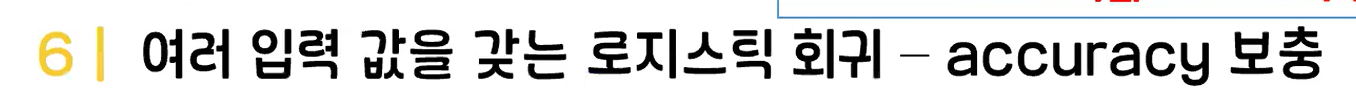

In [ ]:
## Accuracy 보충

# tf.reduce_mean : 배열의 평균

# tf.equal(x, y) : x, y를 비교하여 boolean 값을 반환

# tf.cast : 입력한 값의 결과를 지정한 자료형으로 변환해줌

In [14]:
import tensorflow as tf
import numpy as np

# 실제 y값
Y = tf.constant([0, 0, 0, 0, 0, 0, 1, 1, 1, 1], dtype=tf.float32)
y_data = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.1]
y = tf.constant(y_data, dtype=tf.float32)

# 예측 확률을 0.5기준, 이진 분류
predicted = tf.cast(y > 0.5, dtype=tf.float32) # 조건이 맞으면 T, 조건이 안맞으면 F => cast : T -> 1., F -> 0.
# print(predicted.numpy())

# 정확도 계산
accuracy_tensor = tf.reduce_mean(tf.cast(tf.equal(predicted, Y), dtype=tf.float32))

# 출력
print("예측 결과 (True/False) :", tf.equal(predicted, Y).numpy())
print("예측 결과 (0/1) :", tf.cast(tf.equal(predicted, Y), dtype=tf.float32).numpy())
print("정확도 : ", accuracy_tensor.numpy())

예측 결과 (True/False) : [ True  True  True  True  True False  True  True  True False]
예측 결과 (0/1) : [1. 1. 1. 1. 1. 0. 1. 1. 1. 0.]
정확도 :  0.8


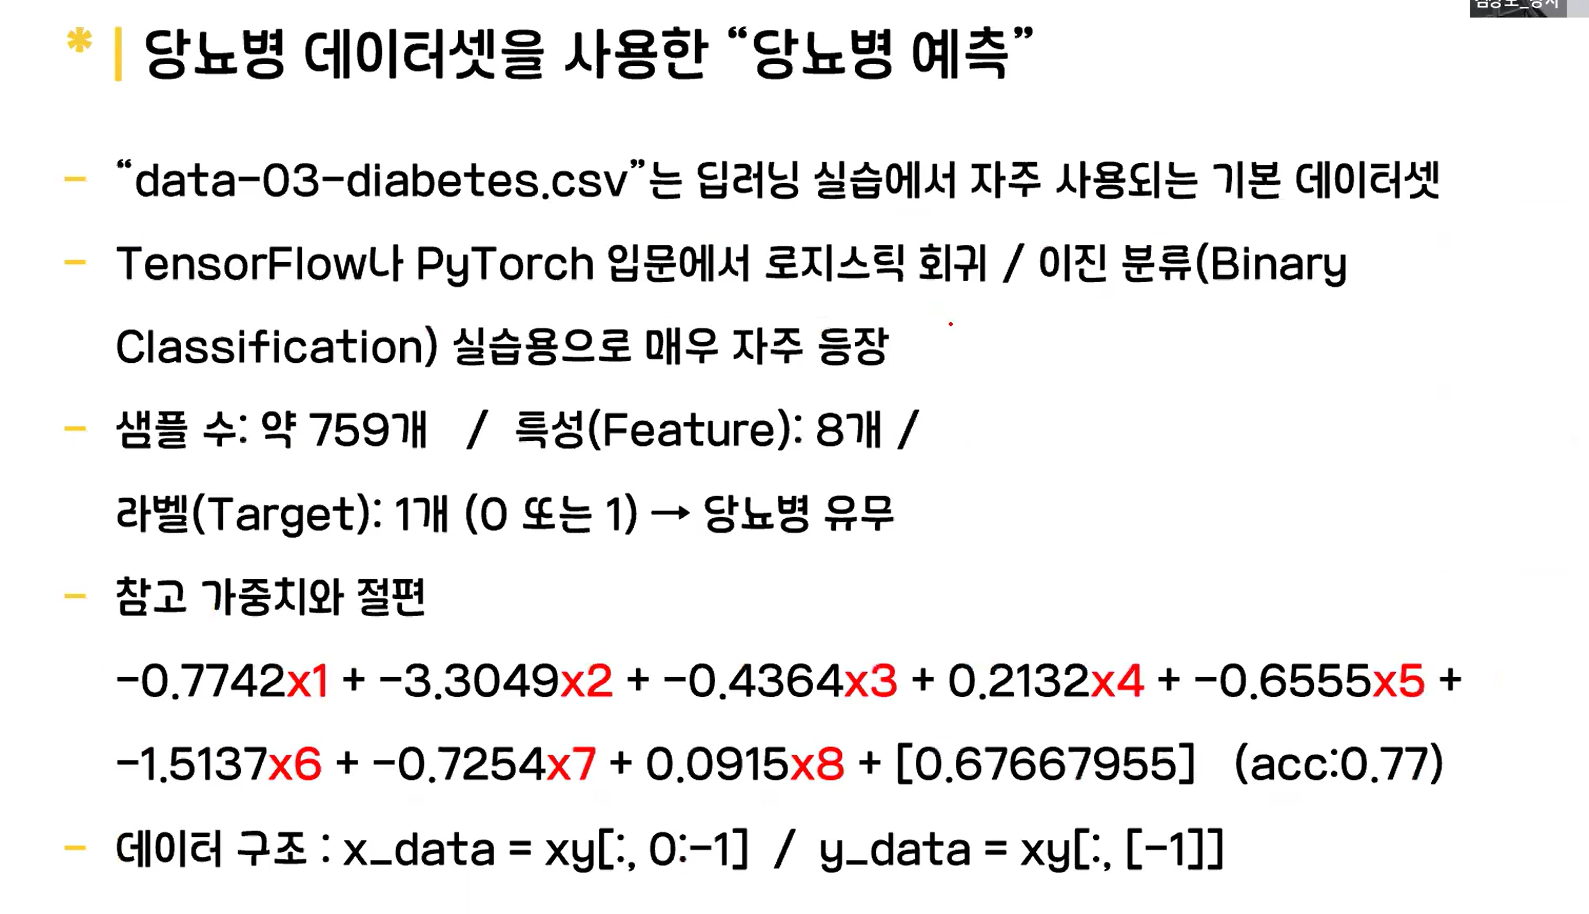

epochs=0, cost=0.79889536, W1=1.51005089, W2=0.42220512,... b=1.06729305, accuracy=0.51778656
epochs=500, cost=0.71584034, W1=1.13905299, W2=0.04514828,... b=1.05946124, accuracy=0.59156785
epochs=1000, cost=0.66253299, W1=0.86969781, W2=-0.30835590,... b=0.94711405, accuracy=0.61791831
epochs=1500, cost=0.62205178, W1=0.64037120, W2=-0.61909217,... b=0.84483248, accuracy=0.65217391
epochs=2000, cost=0.59143746, W1=0.44260836, W2=-0.88977069,... b=0.76104218, accuracy=0.68115942
epochs=2500, cost=0.56827694, W1=0.27268419, W2=-1.12573719,... b=0.69323808, accuracy=0.70619236
epochs=3000, cost=0.55065608, W1=0.12711281, W2=-1.33226931,... b=0.63827986, accuracy=0.71673254
epochs=3500, cost=0.53712541, W1=0.00251260, W2=-1.51401818,... b=0.59351075, accuracy=0.72463768
epochs=4000, cost=0.52661598, W1=-0.10422493, W2=-1.67492080,... b=0.55680794, accuracy=0.73517787
epochs=4500, cost=0.51835090, W1=-0.19584213, W2=-1.81823039,... b=0.52650583, accuracy=0.73913043
epochs=5000, cost=0.5117

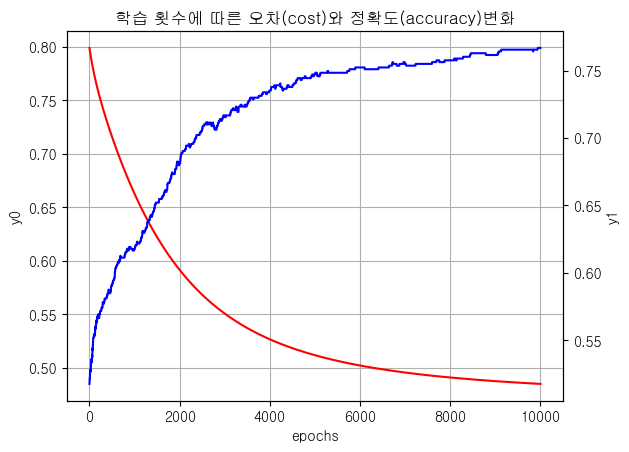

In [24]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def graph() :
    plt.rc('font', family='gulim') # 한글 설정
    plt.rc('axes', unicode_minus = False) # 음수부호 설정
    fig, ax0 = plt.subplots()

    ax1 = ax0.twinx() # x축 공유
    ax0.set_title("학습 횟수에 따른 오차(cost)와 정확도(accuracy)변화")
    ax0.plot(cost_arr, 'r-', label="y0")
    ax0.set_ylabel("y0")
    ax0.grid(True)

    ax1.plot(accuracy_arr, 'b', label="y1")
    ax1.set_ylabel("y1")
    ax1.grid(False)
    ax0.set_xlabel("epochs")

    plt.show()

# 시드 설정
seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

# 당뇨병 데이터 읽어오기
xy = np.loadtxt('data-03-diabetes.csv', delimiter=',', dtype=np.float32)
x_data = xy[:, 0:-1]      ## 0~7열 까지 총 8개 x값
y_data = xy[:, [-1]]      ## 마지막 열(9열)

# 가중치
W = tf.Variable(tf.random.normal([8, 1]), name='weight')
b = tf.Variable(tf.random.normal([1]), name='bias')

# Hypothesis
def hypothesis(W, b) :
    return tf.sigmoid(tf.matmul(x_data, W) + b)

def cost(W, b):
    return - tf.reduce_mean(y_data * tf.math.log(hypothesis(W, b)) + 
                           (1 - y_data) * tf.math.log(1 - hypothesis(W, b)))

opt = tf.keras.optimizers.SGD(learning_rate=0.01)
epoch_arr = []
cost_arr = []
accuracy_arr = []

for step in range(10001):
    with tf.GradientTape() as tape:
        cost_value = cost(W, b)
    gradients = tape.gradient(cost_value, [W, b])
    opt.apply_gradients(zip(gradients, [W, b]))

    predicted = tf.cast(hypothesis(W, b) > 0.5, dtype=tf.float64)
    epoch_arr.append(step)
    cost_arr.append(cost_value.numpy()) 

    # y_data와 계산된 predicted 요소가 일치하는 확률
    accuracy = np.mean(y_data == predicted)
    accuracy_arr.append(accuracy) 
    if step % 500 == 0:
        print("epochs=%d, cost=%.8f, W1=%.8f, W2=%.8f,... b=%.8f, accuracy=%.8f" % 
              (step, cost_value, W.numpy()[0,0], W.numpy()[1,0], b.numpy()[0], accuracy))
graph()
print("==========================================================")